<a href="https://colab.research.google.com/github/FBeni-04/Fundamentals_of_machine_learning/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import re
from collections import Counter, defaultdict
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

import networkx as nx
import numpy as np
from collections import defaultdict
from networkx.algorithms.community import greedy_modularity_communities

#Üzeneteket tartalmazó json file-ok. (a munkám jelentős részét ezzel töltöttem el).
INPUT_FILES = [
    "message_1_javitott.json",
    "message_2_javitott.json",
    "message_3_javitott.json"
]

TOP_N = 10

# Többnyelvű sentiment modell, ergó a magyart is tudja értelmezni
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    use_fast=False,
    top_k=None,
    return_all_scores=True
)



config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.11GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:

# -------------------------------------------------
# SEGÉDFÜGGVÉNYEK
# -------------------------------------------------

def fix_mojibake(text):
    """
    Hibásan dekódolt magyar ékezetek és emojik javítása.
    Példák:
    GÃ¡bor -> Gábor
    ZsÃ³fia -> Zsófia
    ð -> 😆
    â¤ -> ❤
    """
    if not isinstance(text, str):
        return text

    try:
        return text.encode("latin1").decode("utf-8").strip()
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text.strip()


ILLEGAL_EXCEL_CHARS = re.compile(r"[\x00-\x08\x0B-\x0C\x0E-\x1F]")


def clean_for_excel(value):
    """
    Excel által tiltott vezérlőkarakterek törlése.
    Pl. \\x0b, \\x0c stb.
    """
    if isinstance(value, str):
        return ILLEGAL_EXCEL_CHARS.sub("", value)
    return value


def normalize_sentiment_label(label):
    """
    A modell címkéit magyar kategóriákra alakítja.
    cardiffnlp modellnél gyakran:
    LABEL_0 -> negatív
    LABEL_1 -> semleges
    LABEL_2 -> pozitív
    """
    label = label.lower()

    if "positive" in label or "label_2" in label:
        return "pozitív"
    elif "negative" in label or "label_0" in label:
        return "negatív"
    else:
        return "semleges"


def analyze_sentiment(text):
    if not text or not text.strip():
        return "nincs szöveg", 0.0, 0.0

    text = text[:500]

    try:
        raw_results = sentiment_analyzer(text)
        if isinstance(raw_results, list) and len(raw_results) > 0 and isinstance(raw_results[0], list):
            results = raw_results[0]
        elif isinstance(raw_results, list):
            results = raw_results
        else:
            print("Ismeretlen sentiment formátum:", raw_results)
            return "hiba", 0.0, 0.0

        probs = {}

        for item in results:
            label = normalize_sentiment_label(item["label"])
            score = float(item["score"])
            probs[label] = score

        negative = probs.get("negatív", 0.0)
        neutral = probs.get("semleges", 0.0)
        positive = probs.get("pozitív", 0.0)

        model_sentiment_score = positive - negative

        if positive >= neutral and positive >= negative:
            sentiment = "pozitív"
            confidence = positive
        elif negative >= neutral and negative >= positive:
            sentiment = "negatív"
            confidence = negative
        else:
            sentiment = "semleges"
            confidence = neutral

        return sentiment, confidence, model_sentiment_score

    except Exception as e:
        print("Sentiment hiba:", e)
        return "hiba", 0.0, 0.0


def sentiment_to_score(sentiment):
    """
    Szöveges sentiment átalakítása számmá.
    """
    if sentiment == "pozitív":
        return 1.0
    elif sentiment == "negatív":
        return -1.0
    else:
        return 0.0


def score_to_sentiment(score):
    """
    Végső pontszám visszaalakítása kategóriává.
    """
    if score >= 0.35:
        return "pozitív"
    elif score <= -0.35:
        return "negatív"
    else:
        return "semleges"

REACTION_SCORES = {
    "😆": 0.5,
    "❤": 0.6,
    "👍": 0.4,
    "😂": 0.5,
    "😮": 0.0,
    "💀": 0.3,
    "❣️": 0.6,
    "😢": -0.6,
    "🦄": 0.2,
    "😹": 0.5,
    "😍": 0.7,
    "😡": -0.8,
    "☠️": 0.2,
    "💖": 0.7,
    "🤍": 0.6,
    "😭": -0.5,
    "➕": 0.0,
    "🥰": 0.7,
    "🤨": -0.1,
    "☠": -0.5
}

def reaction_adjustment(msg):
    """
    Egy üzenet reakcióiból kiszámolja,
    mennyire tolja el a sentimentet.

    Csak a REACTION_SCORES-ben szereplő reakciókat veszi figyelembe.
    A többi reakció 0 ponttal kimarad.
    """
    reactions = msg.get("reactions", [])

    if not reactions:
        return 0.0

    total = 0.0
    counted = 0

    for reaction in reactions:
        emoji = fix_mojibake(reaction.get("reaction", ""))

        if emoji in REACTION_SCORES:
            total += REACTION_SCORES[emoji]
            counted += 1

    if counted == 0:
        return 0.0

    return total / counted


def top_n_plus_other(counter, n=10):
    """
    Counterből Top N + Egyéb bontás kördiagramhoz.
    """
    most_common = counter.most_common(n)

    top_sum = sum(count for _, count in most_common)
    total_sum = sum(counter.values())
    other_sum = total_sum - top_sum

    labels = [name for name, count in most_common]
    values = [count for name, count in most_common]

    if other_sum > 0:
        labels.append("Egyéb")
        values.append(other_sum)

    return labels, values


def safe_dataframe_for_excel(df):
    """
    DataFrame teljes tisztítása Excel mentés előtt.
    """
    try:
        return df.map(clean_for_excel)
    except AttributeError:
        return df.applymap(clean_for_excel)


def reaction_only_sentiment(msg):
    """
    Csak reakciók alapján becsül sentimentet.
    Akkor hasznos, ha az üzenet kép, GIF, videó stb.
    """
    reactions = msg.get("reactions", [])

    if not reactions:
        return "nincs adat", 0.0

    react_score = reaction_adjustment(msg)

    if react_score >= 0.25:
        return "pozitív", react_score
    elif react_score <= -0.25:
        return "negatív", react_score
    else:
        return "semleges", react_score


In [ ]:
all_messages = []
all_participants = []

for input_file in INPUT_FILES:
    print(f"Beolvasás: {input_file}")

    with open(input_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    all_messages.extend(data.get("messages", []))
    all_participants.extend(data.get("participants", []))

messages = all_messages
participants = all_participants


Beolvasás: message_1_javitott.json
Beolvasás: message_2_javitott.json
Beolvasás: message_3_javitott.json


In [ ]:
message_count = Counter()
reaction_received_count = Counter()
reaction_given_count = Counter()
reaction_type_count = Counter()
monthly_count = Counter()

base_sentiment_total_count = Counter()
final_sentiment_total_count = Counter()

base_sentiment_by_person = defaultdict(Counter)
final_sentiment_by_person = defaultdict(Counter)

all_people = set()
sentiment_rows = []

for p in participants:
    if "name" in p:
        name = fix_mojibake(p["name"])
        all_people.add(name)


for index, msg in enumerate(messages, start=1):
    sender = fix_mojibake(msg.get("sender_name", "Ismeretlen"))
    all_people.add(sender)

    message_count[sender] += 1

    # Dátum
    if "timestamp_ms" in msg:
        dt = datetime.fromtimestamp(msg["timestamp_ms"] / 1000)
        date = dt.strftime("%Y-%m-%d %H:%M:%S")
        month = dt.strftime("%Y-%m")
        monthly_count[month] += 1
    else:
        date = ""
        month = ""

    # Üzenettípus meghatározása
    content = fix_mojibake(msg.get("content", ""))
    has_text = bool(content and content.strip())
    has_reactions = bool(msg.get("reactions", []))

    if has_text:
        message_type = "szöveg"
    elif "photos" in msg:
        message_type = "kép"
    elif "gifs" in msg:
        message_type = "gif"
    elif "videos" in msg:
        message_type = "videó"
    elif "audio_files" in msg:
        message_type = "hang"
    elif "files" in msg:
        message_type = "fájl"
    else:
        message_type = "egyéb"

    photo_uris = []

    if "photos" in msg:
        for photo in msg.get("photos", []):
            uri = photo.get("uri", "")
            if uri:
                photo_uris.append(uri)

    photo_uris_text = " | ".join(photo_uris)

    # Reakciók kigyűjtése
    reactions_text_list = []

    if "reactions" in msg:
        reaction_received_count[sender] += len(msg["reactions"])

        for reaction in msg["reactions"]:
            actor = fix_mojibake(reaction.get("actor", "Ismeretlen"))
            emoji = fix_mojibake(reaction.get("reaction", ""))

            all_people.add(actor)

            reaction_given_count[actor] += 1
            reaction_type_count[emoji] += 1

            reactions_text_list.append(f"{actor}: {emoji}")

    reactions_text = " | ".join(reactions_text_list)
    # -------------------------------------------------
    # SENTIMENT LOGIKA
    # -------------------------------------------------

    # 1. Ha van szöveg: modell elemzi a szöveget, majd a reakciók módosítják
    if has_text:
        base_sentiment, model_score, model_sentiment_score = analyze_sentiment(content)

        react_score = reaction_adjustment(msg)

        final_score = model_sentiment_score + react_score
        final_sentiment = score_to_sentiment(final_score)

        analysis_source = "szöveg + reakció"

    # 2. Ha nincs szöveg, de van reakció: csak reakció alapján becsülünk
    elif has_reactions:
        base_sentiment = "nincs szöveg"
        model_score = 0.0
        model_sentiment_score = 0.0

        react_score = reaction_adjustment(msg)
        final_score = react_score
        final_sentiment = score_to_sentiment(final_score)

        analysis_source = "csak reakció"

    # 3. Ha se szöveg, se reakció nincs
    else:
        base_sentiment = "nincs szöveg"
        model_score = 0.0
        model_sentiment_score = 0.0
        react_score = 0.0
        final_score = 0.0
        final_sentiment = "nincs adat"

        analysis_source = "nincs adat"

    # Összesítések
    base_sentiment_total_count[base_sentiment] += 1
    final_sentiment_total_count[final_sentiment] += 1

    base_sentiment_by_person[sender][base_sentiment] += 1
    final_sentiment_by_person[sender][final_sentiment] += 1

    sentiment_rows.append({
        "Sorszám": index,
        "Dátum": date,
        "Hónap": month,
        "Küldő": sender,
        "Üzenettípus": message_type,
        "Szöveg": content,
        "Kép URI": photo_uris_text,
        "Kapott reakciók száma": len(msg.get("reactions", [])),
        "Reakciók": reactions_text,
        "Elemzés forrása": analysis_source,
        "Alap sentiment": base_sentiment,
        "Modell biztosság": round(model_score, 4),
        "Modell sentiment pontszám": round(model_sentiment_score, 4),
        "Reakciós pontszám": round(react_score, 4),
        "Végső pontszám": round(final_score, 4),
        "Végső sentiment": final_sentiment
    })

    if index % 100 == 0:
        print(f"Feldolgozva: {index}/{len(messages)} üzenet")


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Feldolgozva: 100/26787 üzenet
Feldolgozva: 200/26787 üzenet
Feldolgozva: 300/26787 üzenet
Feldolgozva: 400/26787 üzenet
Feldolgozva: 500/26787 üzenet
Feldolgozva: 600/26787 üzenet
Feldolgozva: 700/26787 üzenet
Feldolgozva: 800/26787 üzenet
Feldolgozva: 900/26787 üzenet
Feldolgozva: 1000/26787 üzenet
Feldolgozva: 1100/26787 üzenet
Feldolgozva: 1200/26787 üzenet
Feldolgozva: 1300/26787 üzenet
Feldolgozva: 1400/26787 üzenet
Feldolgozva: 1500/26787 üzenet
Feldolgozva: 1600/26787 üzenet
Feldolgozva: 1700/26787 üzenet
Feldolgozva: 1800/26787 üzenet
Feldolgozva: 1900/26787 üzenet
Feldolgozva: 2000/26787 üzenet
Feldolgozva: 2100/26787 üzenet
Feldolgozva: 2200/26787 üzenet
Feldolgozva: 2300/26787 üzenet
Feldolgozva: 2400/26787 üzenet
Feldolgozva: 2500/26787 üzenet
Feldolgozva: 2600/26787 üzenet
Feldolgozva: 2700/26787 üzenet
Feldolgozva: 2800/26787 üzenet
Feldolgozva: 2900/26787 üzenet
Feldolgozva: 3000/26787 üzenet
Feldolgozva: 3100/26787 üzenet
Feldolgozva: 3200/26787 üzenet
Feldolgozva: 3300

In [ ]:
with open("osszes_szemely.txt", "w", encoding="utf-8") as f:
    for name in sorted(all_people):
        f.write(name + "\n")


people_rows = []

for name in sorted(all_people):
    people_rows.append({
        "Név": name,

        "Üzenetek száma": message_count[name],
        "Kapott reakciók száma": reaction_received_count[name],
        "Adott reakciók száma": reaction_given_count[name],

        "Alap pozitív üzenetek": base_sentiment_by_person[name]["pozitív"],
        "Alap semleges üzenetek": base_sentiment_by_person[name]["semleges"],
        "Alap negatív üzenetek": base_sentiment_by_person[name]["negatív"],

        "Korrigált pozitív üzenetek": final_sentiment_by_person[name]["pozitív"],
        "Korrigált semleges üzenetek": final_sentiment_by_person[name]["semleges"],
        "Korrigált negatív üzenetek": final_sentiment_by_person[name]["negatív"]
    })


df_sentiment_messages = pd.DataFrame(sentiment_rows)

df_monthly = pd.DataFrame(
    sorted(monthly_count.items()),
    columns=["Hónap", "Üzenetek száma"]
)


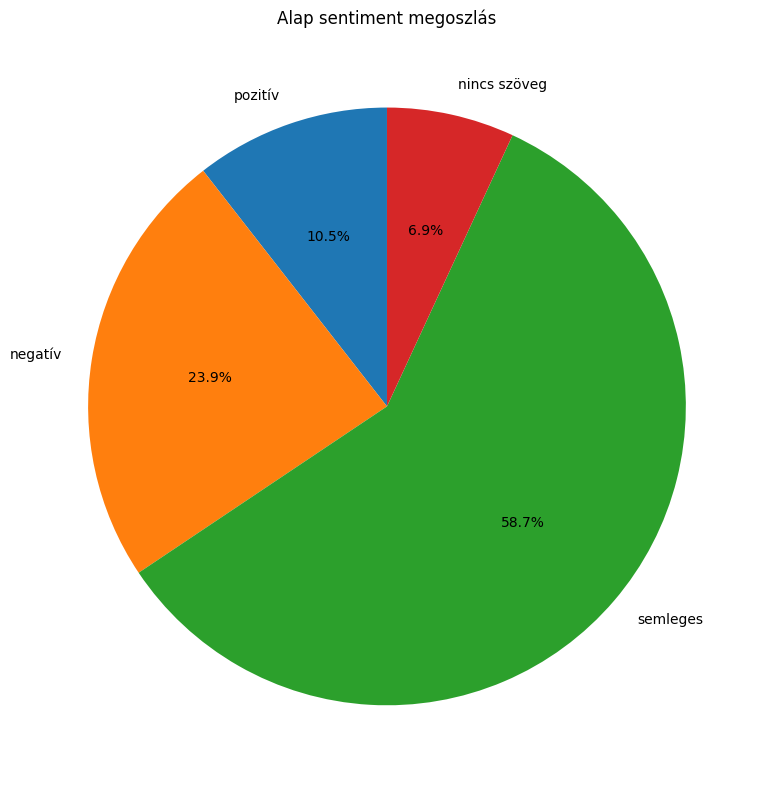

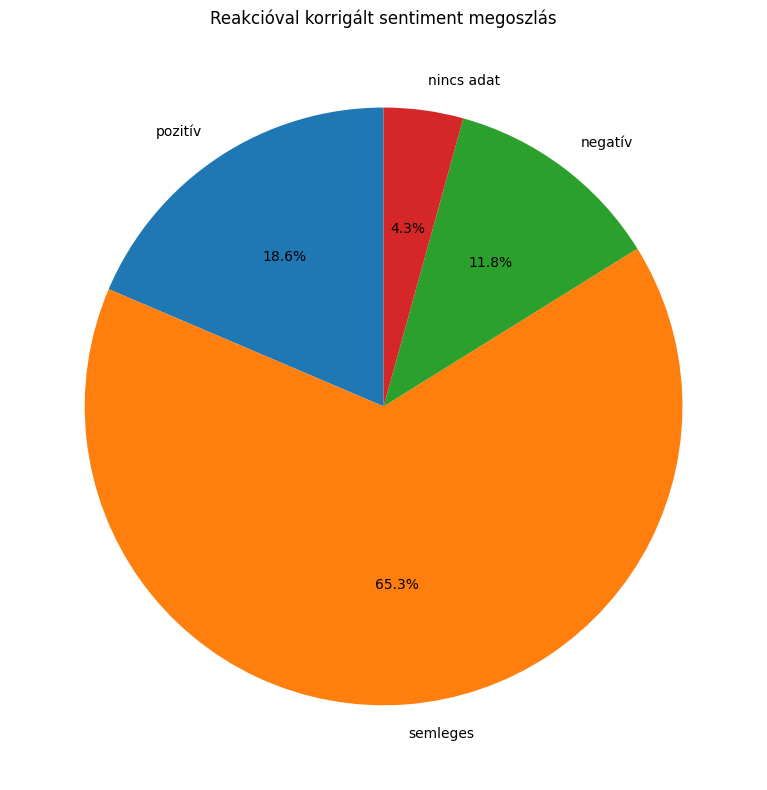

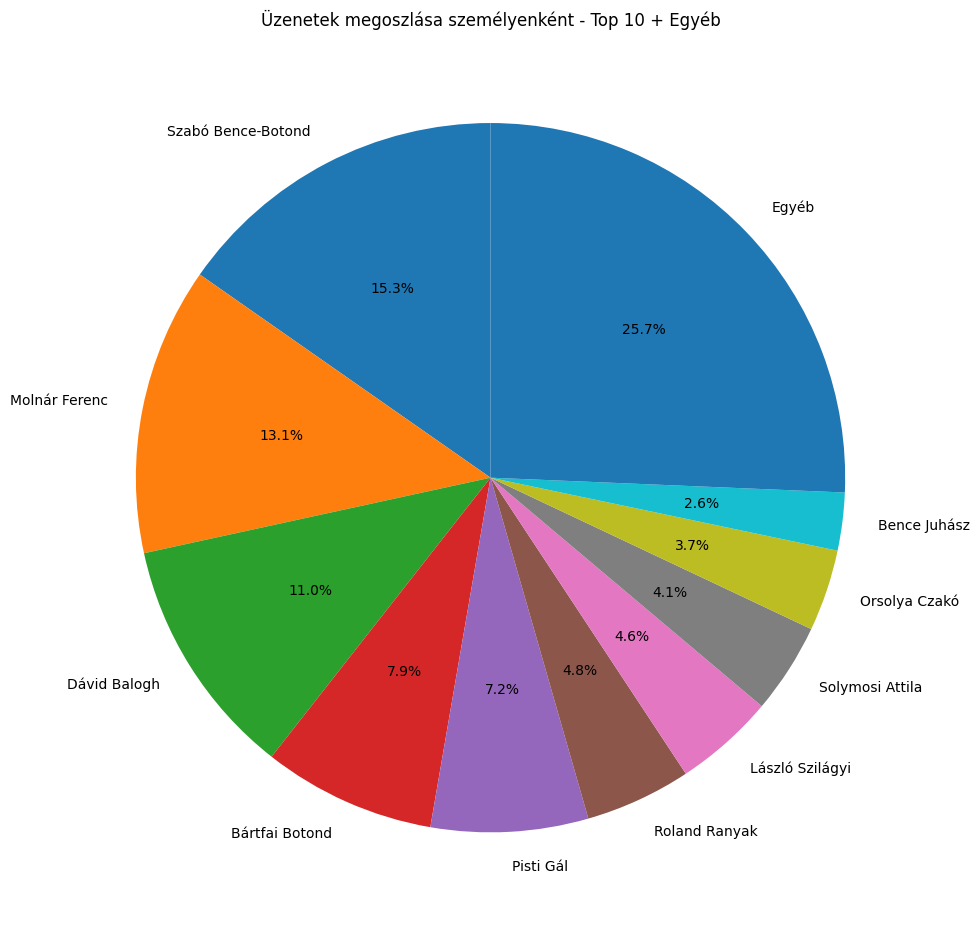

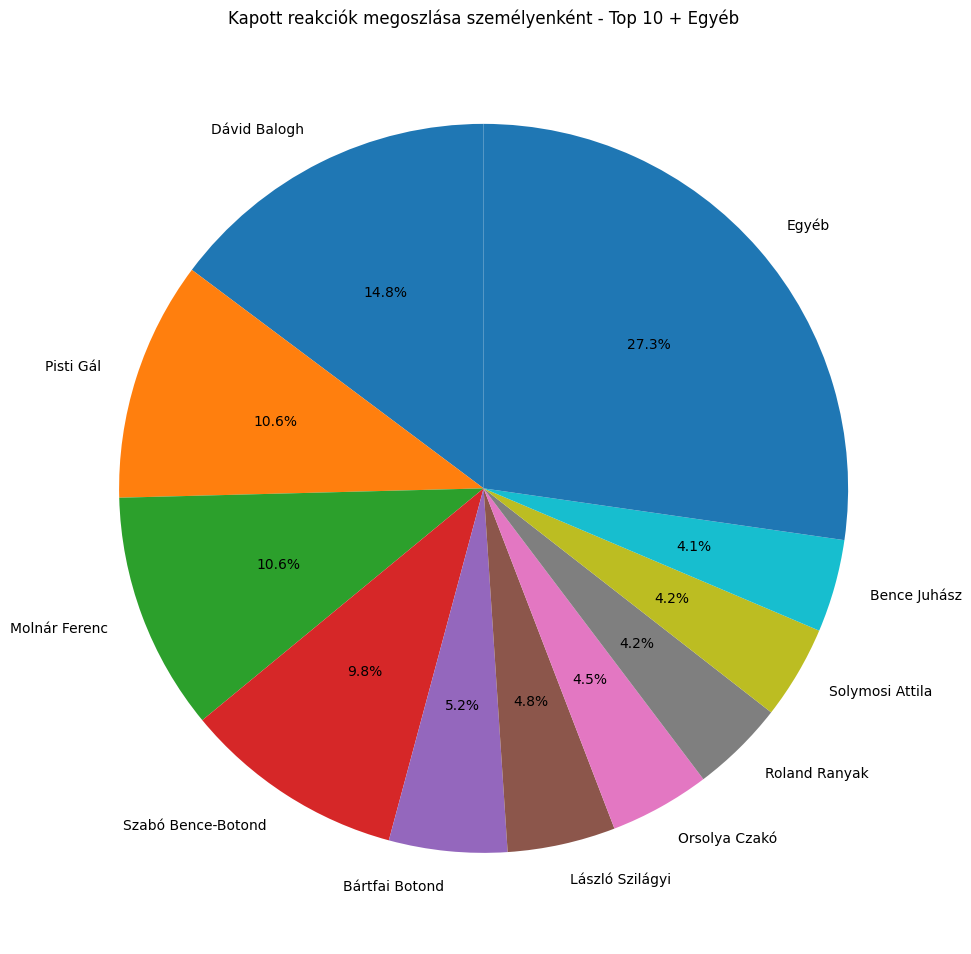

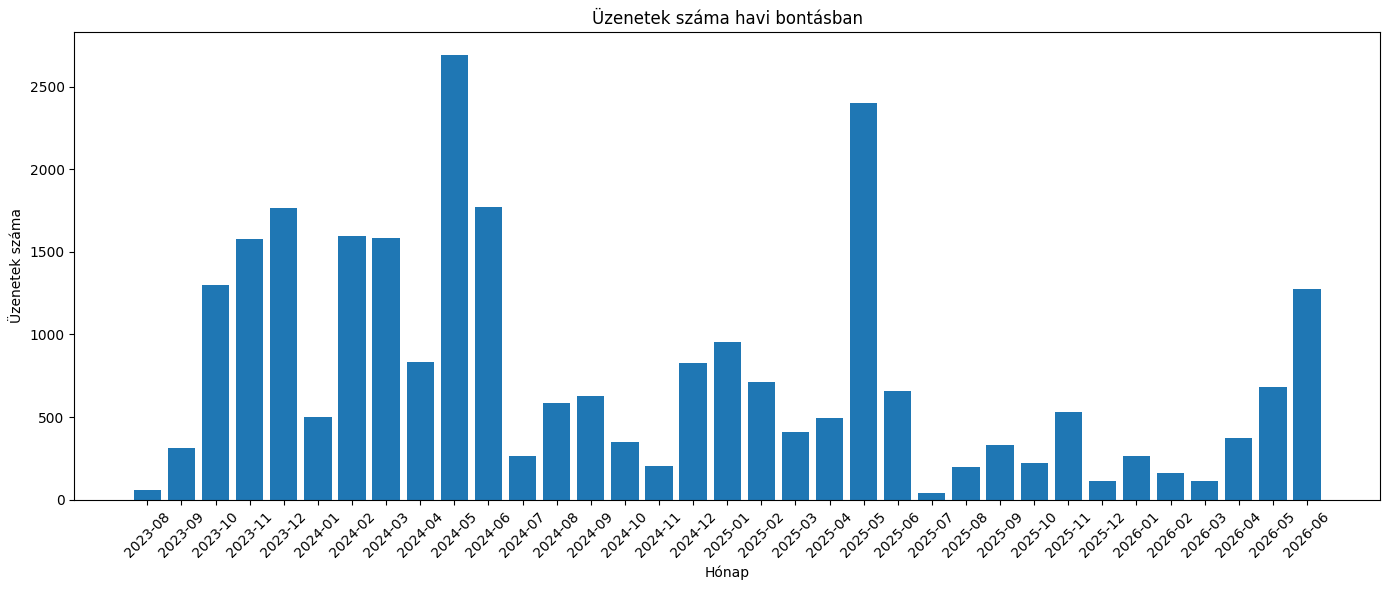

/tmp/ipykernel_562/2150088022.py:102: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_562/2150088022.py:102: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_562/2150088022.py:102: UserWarning: Glyph 129412 (\N{UNICORN FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_562/2150088022.py:103: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig("top_reakciotipusok.png", dpi=200)
/tmp/ipykernel_562/2150088022.py:103: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.savefig("top_reakciotipusok.png", dpi=200)
/tmp/ipykernel_562/2150088022.py:103: UserWarning: Glyph 129412 (\N{UNICORN FACE}) missing from font(s) DejaVu Sans.
  plt.savefig("top_reakciotipusok.png", dpi=200)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 

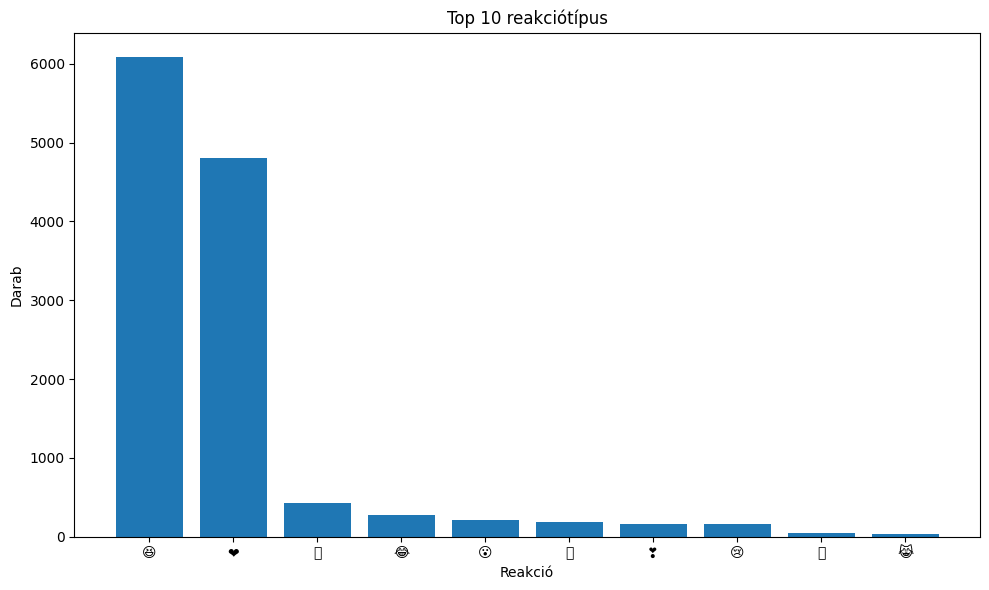

In [ ]:
# -------------------------------------------------
# DIAGRAM 1: ALAP SENTIMENT MEGOSZLÁS
# -------------------------------------------------

plt.figure(figsize=(8, 8))
plt.pie(
    list(base_sentiment_total_count.values()),
    labels=list(base_sentiment_total_count.keys()),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Alap sentiment megoszlás")
plt.tight_layout()
#plt.savefig("alap_sentiment_megoszlas.png", dpi=200)
plt.show()


# -------------------------------------------------
# DIAGRAM 2: REAKCIÓVAL KORRIGÁLT SENTIMENT MEGOSZLÁS
# -------------------------------------------------

plt.figure(figsize=(8, 8))
plt.pie(
    list(final_sentiment_total_count.values()),
    labels=list(final_sentiment_total_count.keys()),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Reakcióval korrigált sentiment megoszlás")
plt.tight_layout()
#plt.savefig("korrigalt_sentiment_megoszlas.png", dpi=200)
plt.show()


# -------------------------------------------------
# DIAGRAM 3: ÜZENETEK SZEMÉLYENKÉNT - KÖRDIAGRAM
# -------------------------------------------------

labels, values = top_n_plus_other(message_count, n=TOP_N)

plt.figure(figsize=(10, 10))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title(f"Üzenetek megoszlása személyenként - Top {TOP_N} + Egyéb")
plt.tight_layout()
#plt.savefig("kor_uzenetek_top10.png", dpi=200)
plt.show()


# -------------------------------------------------
# DIAGRAM 4: KAPOTT REAKCIÓK SZEMÉLYENKÉNT - KÖRDIAGRAM
# -------------------------------------------------

labels, values = top_n_plus_other(reaction_received_count, n=TOP_N)

plt.figure(figsize=(10, 10))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title(f"Kapott reakciók megoszlása személyenként - Top {TOP_N} + Egyéb")
plt.tight_layout()
#plt.savefig("kor_kapott_reakciok_top10.png", dpi=200)
plt.show()


# -------------------------------------------------
# DIAGRAM 5: HAVI ÜZENETSZÁM OSZLOPDIAGRAM
# -------------------------------------------------

plt.figure(figsize=(14, 6))
plt.bar(df_monthly["Hónap"], df_monthly["Üzenetek száma"])
plt.xlabel("Hónap")
plt.ylabel("Üzenetek száma")
plt.title("Üzenetek száma havi bontásban")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("havi_uzenetek_oszlopdiagram.png", dpi=200)
plt.show()


# -------------------------------------------------
# DIAGRAM 6: TOP REAKCIÓTÍPUSOK
# -------------------------------------------------

df_top_reactions = pd.DataFrame(
    reaction_type_count.most_common(10),
    columns=["Reakció", "Darab"]
)

plt.figure(figsize=(10, 6))
plt.bar(df_top_reactions["Reakció"], df_top_reactions["Darab"])
plt.xlabel("Reakció")
plt.ylabel("Darab")
plt.title("Top 10 reakciótípus")
plt.tight_layout()
#plt.savefig("top_reakciotipusok.png", dpi=200)
plt.show()


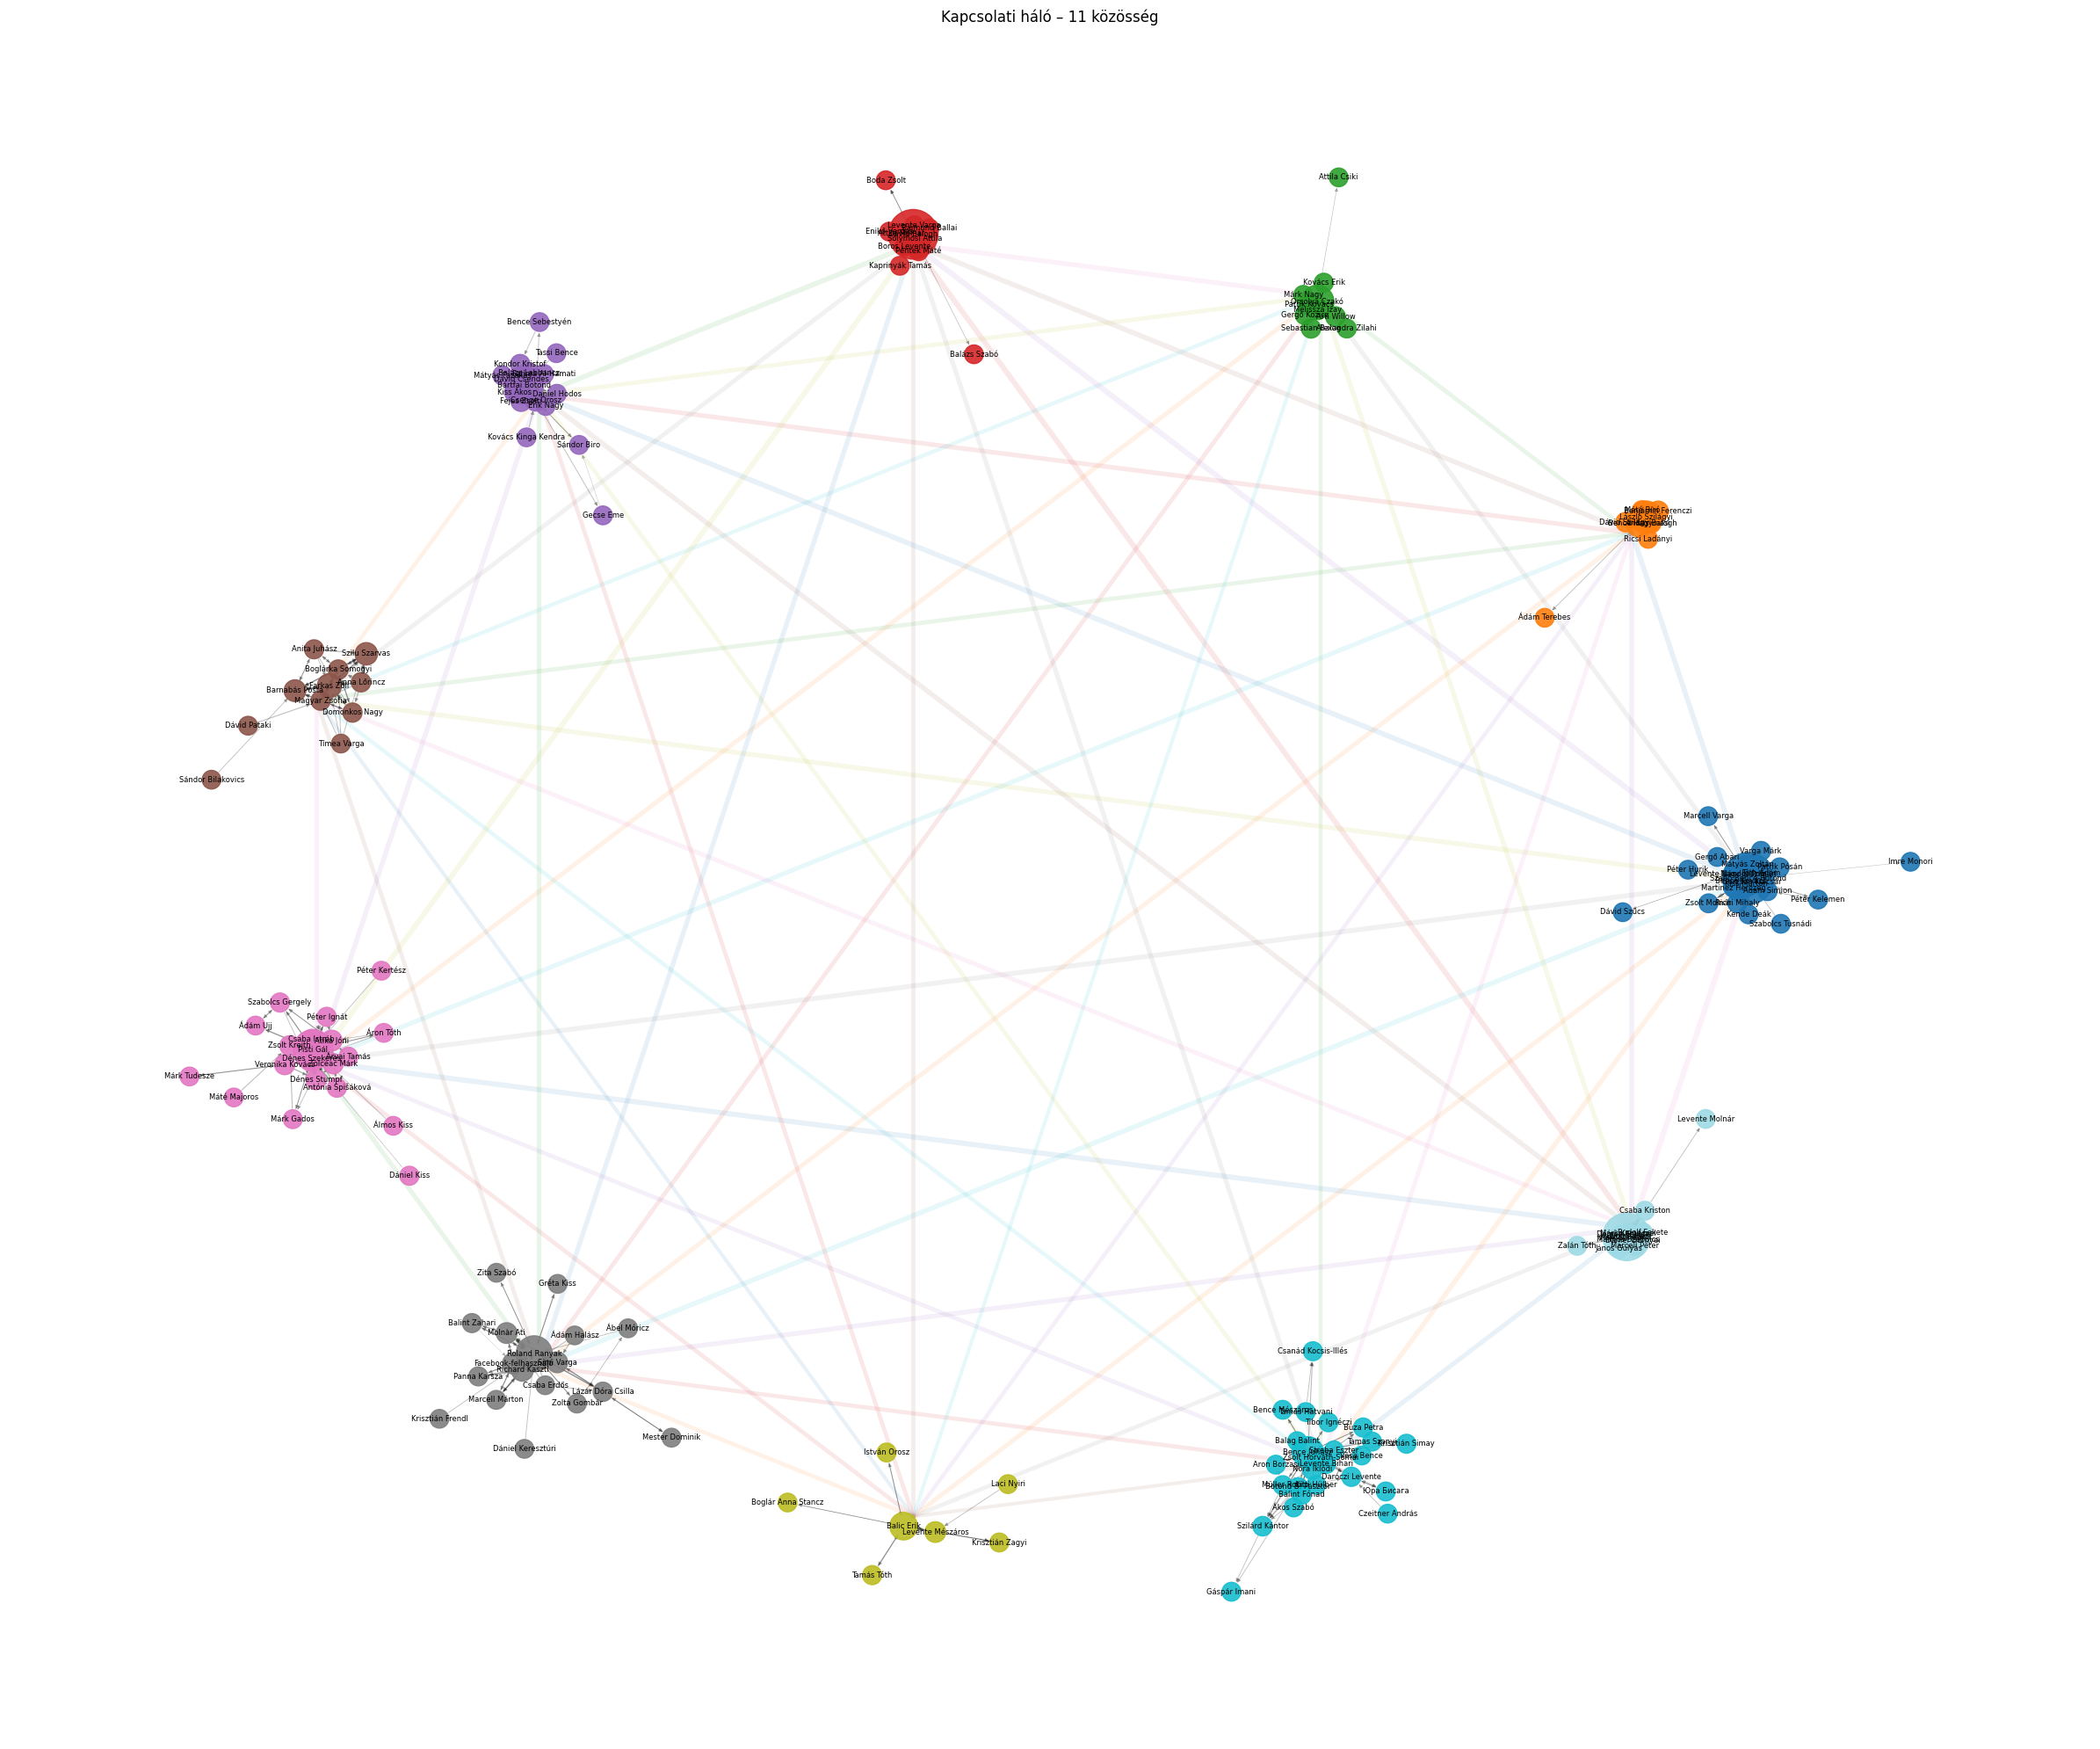


Személyek száma: 161
Kapcsolatok száma: 3477
Közösségek száma: 11
1. közösség: 22 fő
2. közösség: 8 fő
3. közösség: 10 fő
4. közösség: 11 fő
5. közösség: 16 fő
6. közösség: 11 fő
7. közösség: 20 fő
8. közösség: 18 fő
9. közösség: 7 fő
10. közösség: 25 fő
11. közösség: 13 fő


In [ ]:
MESSAGE_WINDOW_MINUTES = 5
MAX_PREVIOUS_PEOPLE = 3

MESSAGE_WEIGHT = 1.0
REACTION_WEIGHT = 2.0

G = nx.DiGraph()


for person in all_people:
    G.add_node(
        person,
        messages=message_count[person],
        reactions_given=reaction_given_count[person],
        reactions_received=reaction_received_count[person]
    )


messages_sorted = sorted(
    messages,
    key=lambda msg: msg.get("timestamp_ms", 0)
)


def add_interaction(source, target, message_inc=0.0, reaction_inc=0.0):
    if not source or not target or source == target:
        return

    if not G.has_edge(source, target):
        G.add_edge(
            source,
            target,
            message_score=0.0,
            reaction_count=0,
            weight=0.0
        )

    G[source][target]["message_score"] += message_inc
    G[source][target]["reaction_count"] += reaction_inc

    G[source][target]["weight"] = (
        G[source][target]["message_score"] * MESSAGE_WEIGHT
        + G[source][target]["reaction_count"] * REACTION_WEIGHT
    )


for i, msg in enumerate(messages_sorted):
    sender = fix_mojibake(msg.get("sender_name", "Ismeretlen"))
    current_ts = msg.get("timestamp_ms")

    if current_ts is None:
        continue

    seen_people = set()

    for j in range(i - 1, -1, -1):
        prev_msg = messages_sorted[j]
        prev_ts = prev_msg.get("timestamp_ms")

        if prev_ts is None:
            continue

        diff_minutes = (current_ts - prev_ts) / 60000

        if diff_minutes > MESSAGE_WINDOW_MINUTES:
            break

        prev_sender = fix_mojibake(
            prev_msg.get("sender_name", "Ismeretlen")
        )

        if prev_sender == sender:
            continue

        if prev_sender in seen_people:
            continue

        seen_people.add(prev_sender)

        time_factor = 1 - (
            diff_minutes / MESSAGE_WINDOW_MINUTES
        )

        add_interaction(
            sender,
            prev_sender,
            message_inc=max(time_factor, 0.1)
        )

        if len(seen_people) >= MAX_PREVIOUS_PEOPLE:
            break


for msg in messages_sorted:
    sender = fix_mojibake(
        msg.get("sender_name", "Ismeretlen")
    )

    for reaction in msg.get("reactions", []):
        actor = fix_mojibake(
            reaction.get("actor", "Ismeretlen")
        )

        add_interaction(
            actor,
            sender,
            reaction_inc=1
        )


nodes_to_remove = [
    node
    for node in G.nodes()
    if message_count[node] == 0
    and reaction_given_count[node] == 0
]

G.remove_nodes_from(nodes_to_remove)
G.remove_nodes_from(list(nx.isolates(G)))


pagerank = nx.pagerank(
    G,
    weight="weight"
)


for u, v, data in G.edges(data=True):
    weight = data.get("weight", 0)

    if weight > 0:
        data["distance"] = 1 / weight
    else:
        data["distance"] = 1.0


betweenness = nx.betweenness_centrality(
    G,
    weight="distance"
)


degree_centrality = nx.degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)


UG = nx.Graph()

for node, data in G.nodes(data=True):
    UG.add_node(node, **data)

for u, v, data in G.edges(data=True):
    weight = data.get("weight", 0)

    if UG.has_edge(u, v):
        UG[u][v]["weight"] += weight
    else:
        UG.add_edge(
            u,
            v,
            weight=weight
        )


weights = [
    data["weight"]
    for _, _, data in UG.edges(data=True)
]

threshold = np.percentile(weights, 25)

UG_cluster = nx.Graph()

for u, v, data in UG.edges(data=True):
    if data["weight"] >= threshold:
        UG_cluster.add_edge(
            u,
            v,
            weight=data["weight"]
        )


communities = list(
    nx.community.louvain_communities(
        UG_cluster,
        weight="weight",
        resolution=1.4,
        seed=42
    )
)


community_map = {}

for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i


missing_nodes = [
    node
    for node in G.nodes()
    if node not in community_map
]


for node in missing_nodes:

    cluster_weights = defaultdict(float)

    for neighbor in UG.neighbors(node):

        if neighbor not in community_map:
            continue

        cluster_id = community_map[neighbor]

        cluster_weights[cluster_id] += (
            UG[node][neighbor]["weight"]
        )


    if cluster_weights:

        best_cluster = max(
            cluster_weights,
            key=cluster_weights.get
        )

        communities[best_cluster].add(node)
        community_map[node] = best_cluster

    else:

        new_cluster_id = len(communities)

        communities.append(
            {node}
        )

        community_map[node] = new_cluster_id

def clustered_layout(G, communities, cluster_distance=14.0):
    pos = {}

    angles = np.linspace(
        0,
        2 * np.pi,
        len(communities),
        endpoint=False
    )

    for i, community in enumerate(communities):
        center = np.array([
            np.cos(angles[i]) * cluster_distance,
            np.sin(angles[i]) * cluster_distance
        ])

        subgraph = G.subgraph(community)

        if len(subgraph) == 1:
            node = list(subgraph.nodes())[0]
            pos[node] = center
            continue

        local_pos = nx.spring_layout(
            subgraph,
            weight="weight",
            seed=42,
            k=1.3,
            iterations=300
        )

        nodes = list(local_pos.keys())

        coords = np.array([
            local_pos[node]
            for node in nodes
        ])

        max_dist = np.max(
            np.linalg.norm(coords, axis=1)
        )

        if max_dist > 0:
            coords = coords / max_dist

        local_scale = 1.5 + np.sqrt(len(community)) * 0.35

        for node, coord in zip(nodes, coords):
            pos[node] = center + coord * local_scale

    return pos


pos = clustered_layout(
    G,
    communities,
    cluster_distance=14.0
)


internal_edges = [
    (u, v)
    for u, v in G.edges()
    if community_map[u] == community_map[v]
]


community_edges = defaultdict(float)

for u, v, data in G.edges(data=True):
    cu = community_map[u]
    cv = community_map[v]

    if cu != cv:
        pair = tuple(sorted((cu, cv)))
        community_edges[pair] += data.get("weight", 0.0)


community_centers = {}

for i, community in enumerate(communities):
    coords = np.array([
        pos[node]
        for node in community
    ])

    community_centers[i] = coords.mean(axis=0)


node_colors = [
    community_map[node]
    for node in G.nodes()
]


node_sizes = [
    220 + pagerank[node] * 14000
    for node in G.nodes()
]


plt.figure(figsize=(24, 20))


for (c1, c2), weight in community_edges.items():
    x1, y1 = community_centers[c1]
    x2, y2 = community_centers[c2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=0.4 + np.log1p(weight) * 0.5,
        alpha=0.10,
        zorder=0
    )


nx.draw_networkx_edges(
    G,
    pos,
    edgelist=internal_edges,
    width=[
        0.25 + np.log1p(G[u][v]["weight"]) * 0.35
        for u, v in internal_edges
    ],
    alpha=0.25,
    arrows=True,
    arrowsize=6
)


nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    node_size=node_sizes,
    alpha=0.9
)


nx.draw_networkx_labels(
    G,
    pos,
    font_size=6
)


plt.title(
    f"Kapcsolati háló – {len(communities)} közösség"
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "kapcsolati_halo_kozossegek.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


nx.write_graphml(
    G,
    "kapcsolati_halo.graphml"
)


print()
print("Személyek száma:", G.number_of_nodes())
print("Kapcsolatok száma:", G.number_of_edges())
print("Közösségek száma:", len(communities))


for i, community in enumerate(communities, start=1):
    print(
        f"{i}. közösség:",
        len(community),
        "fő"
    )

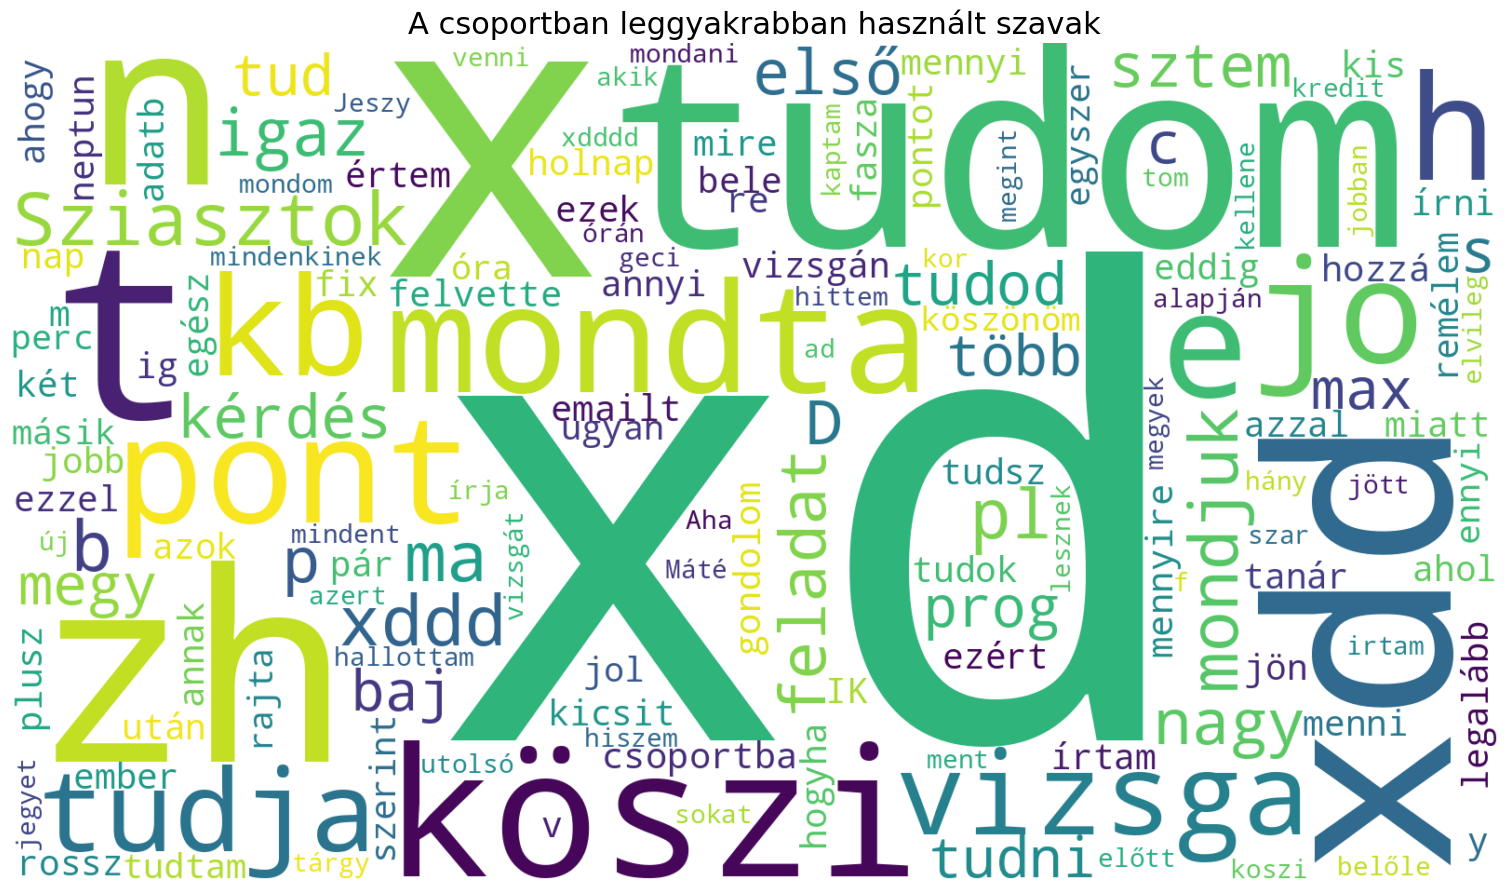

In [ ]:
# -------------------------------------------------
# WORD CLOUD – LEGGYAKORIBB SZAVAK AZ ÜZENETEKBEN
# -------------------------------------------------

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re


# Magyar stopwordök
hungarian_stopwords = {
    "a", "az", "egy", "és", "hogy", "is", "de", "nem", "igen",
    "ha", "van", "volt", "lesz", "vagy", "mert", "meg", "már",
    "még", "mint", "csak", "akkor", "itt", "ott", "ezt", "azt",
    "ez", "aki", "ami", "amúgy", "úgy", "így", "én", "te", "ő",
    "mi", "ti", "ők", "nekem", "neked", "neki", "nálam", "nálad",
    "sem", "se", "igen", "jó", "jól", "na", "hát", "persze",
    "szerintem", "most", "majd", "kell", "lehet", "lenne",
    "vagyok", "vagyunk", "vannak", "valami", "valaki",
    "miért", "mikor", "hol", "milyen", "nagyon", "nincs", "hat", "elég", "ja",
    "minden", "be", "ki", "le", "el", "fel", "át", "rá", "ide", "oda", "szét",
    "össze", "vissza", "amugy", "benne", "mindenki", "alatt", "felett", "mit",
    "valakinek", "amikor", "akinek", "voltam", "olyan", "en", "mar", "ilyen",
    "volna", "legyek", "lett", "azért", "semmi", "más", "szóval", "legyen",
    "o", "biztos", "amit", "mindig", "sok", "fog", "erre", "megvan", "mivel",
    "valami", "ugy", "igy", "vele", "voltak", "kellett", "mind", "pedig",
    "esetleg", "kéne", "aztán", "tényleg", "valamit", "es", "vagyis",
    "egyik", "ra", "ossze", "viszont", "et", "azon", "arra", "utána",
    "ne", "ugye", "annyira", "engem", "asszem", "nekünk", "hanem", "oke", "ok",
    "okés", "oké", "inkább", "semmit", "melyik"
}

stopwords = STOPWORDS.union(hungarian_stopwords)


# Összes szöveges üzenet összegyűjtése
all_texts = []

for msg in messages:

    content = fix_mojibake(
        msg.get("content", "")
    )

    if not content:
        continue

    # URL-ek eltávolítása
    content = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        content
    )

    # E-mail címek eltávolítása
    content = re.sub(
        r"\S+@\S+",
        " ",
        content
    )

    # Számok eltávolítása
    content = re.sub(
        r"\b\d+\b",
        " ",
        content
    )

    # Csak betűk és szóközök maradjanak
    # magyar ékezetes karakterek megtartásával
    content = re.sub(
        r"[^a-zA-ZáéíóöőúüűÁÉÍÓÖŐÚÜŰ\s]",
        " ",
        content
    )

    # Többszörös szóközök
    content = re.sub(
        r"\s+",
        " ",
        content
    ).strip()

    if content:
        all_texts.append(content)


# Egyetlen nagy szöveg
wordcloud_text = " ".join(all_texts)


# Word Cloud létrehozása
wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    max_words=150,
    min_font_size=10
).generate(wordcloud_text)


# Megjelenítés
plt.figure(figsize=(16, 9))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "A csoportban leggyakrabban használt szavak",
    fontsize=22
)

plt.tight_layout()

plt.savefig(
    "wordcloud_osszes_uzenet.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
blocks = []

current_texts = []
current_senders = set()
current_start = None

messages_sorted = sorted(
    messages,
    key=lambda msg: msg.get("timestamp_ms", 0)
)

for msg in messages_sorted:
    ts = msg.get("timestamp_ms", 0)
    sender = msg.get("sender_name", "Ismeretlen")
    text = msg.get("content", "")

    if not text:
        continue

    text = fix_mojibake(text).strip()

    if not text:
        continue

    if current_start is None:
        current_start = ts

    if ts - current_start <= 5 * 60 * 1000:
        current_texts.append(text)
        current_senders.add(sender)
    else:
        if current_texts:
            blocks.append({
                "text": " ".join(current_texts),
                "senders": list(current_senders),
                "start_ts": current_start
            })

        current_texts = [text]
        current_senders = {sender}
        current_start = ts

if current_texts:
    blocks.append({
        "text": " ".join(current_texts),
        "senders": list(current_senders),
        "start_ts": current_start
    })

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import umap
import hdbscan
import numpy as np
import pandas as pd
import plotly.express as px
import re


# -------------------------------------------------
# 1. TISZTÍTÓ FÜGGVÉNYEK
# -------------------------------------------------

def clean_for_embedding(text):
    text = str(text)

    # Emoji és egyéb speciális karakterek eltávolítása
    text = re.sub(
        r"[^\w\sáéíóöőúüűÁÉÍÓÖŐÚÜŰ.,!?-]",
        " ",
        text
    )

    text = re.sub(r"\s+", " ", text).strip()
    return text


def is_system_message(text):
    text = str(text).lower()

    patterns = [
        r"felvette .* a csoportba",
        r"eltávolította .* a csoportból",
        r"csatlakozott a csoporthoz",
        r"kilépett a csoportból",
        r"megváltoztatta a csoport nevét",
        r"megváltoztatta a csoport képét"
    ]

    return any(
        re.search(pattern, text)
        for pattern in patterns
    )


# -------------------------------------------------
# 2. BLOKKOK SZŰRÉSE
# -------------------------------------------------

filtered_blocks = []

for block in blocks:
    original_text = str(block["text"]).strip()

    if not original_text:
        continue

    if is_system_message(original_text):
        continue

    cleaned_text = clean_for_embedding(original_text)

    # Emoji-only, egy-két szavas, túl rövid blokkok kizárása
    if len(cleaned_text.split()) < 3:
        continue

    filtered_blocks.append({
        **block,
        "text_clean": cleaned_text
    })


texts_original = [
    block["text"]
    for block in filtered_blocks
]

texts = [
    block["text_clean"]
    for block in filtered_blocks
]

print("Eredeti blokkok száma:", len(blocks))
print("Szűrt blokkok száma:", len(filtered_blocks))


# -------------------------------------------------
# 3. EMBEDDING
# -------------------------------------------------

model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=64
)

embeddings = normalize(embeddings)


# -------------------------------------------------
# 4. UMAP 15D A KLASZTEREZÉSHEZ
# -------------------------------------------------

reducer_cluster = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embeddings_reduced = reducer_cluster.fit_transform(
    embeddings
)


# -------------------------------------------------
# 5. HDBSCAN
# -------------------------------------------------

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=3,
    metric="euclidean",
    cluster_selection_method="leaf"
)

cluster_labels = clusterer.fit_predict(
    embeddings_reduced
)


cluster_count = (
    len(set(cluster_labels))
    - (1 if -1 in cluster_labels else 0)
)

noise_count = np.sum(
    cluster_labels == -1
)

noise_ratio = (
    noise_count /
    len(cluster_labels)
    * 100
)

print("Klaszterek száma:", cluster_count)
print("Zajpontok száma:", noise_count)
print(f"Zaj aránya: {noise_ratio:.1f}%")


# -------------------------------------------------
# 6. UMAP 2D CSAK A VIZUALIZÁCIÓHOZ
# -------------------------------------------------

reducer_visual = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer_visual.fit_transform(
    embeddings
)


# -------------------------------------------------
# 7. DATAFRAME
# -------------------------------------------------

df_embedding = pd.DataFrame({
    "x": embedding_2d[:, 0],
    "y": embedding_2d[:, 1],
    "Szöveg": texts_original,
    "Tisztított szöveg": texts,
    "cluster": cluster_labels
})


df_embedding["Klaszter"] = (
    df_embedding["cluster"]
    .apply(
        lambda x:
            "Zaj / outlier"
            if x == -1
            else f"Klaszter {x + 1}"
    )
)


df_embedding["Személyek"] = [
    ", ".join(block["senders"])
    for block in filtered_blocks
]


# -------------------------------------------------
# 8. SCATTER PLOT
# -------------------------------------------------

fig = px.scatter(
    df_embedding,
    x="x",
    y="y",
    color="Klaszter",
    hover_data={
        "Szöveg": True,
        "Személyek": True,
        "x": False,
        "y": False,
        "cluster": False,
        "Tisztított szöveg": False
    },
    title="Messenger beszélgetési blokkok szemantikai klaszterei"
)

fig.update_traces(
    marker=dict(
        size=7,
        opacity=0.7
    )
)

fig.update_layout(
    xaxis_title="UMAP 1",
    yaxis_title="UMAP 2"
)

fig.show()


# -------------------------------------------------
# 9. KLASZTEREK MÉRETE
# -------------------------------------------------

cluster_sizes = (
    df_embedding[
        df_embedding["cluster"] != -1
    ]
    ["cluster"]
    .value_counts()
    .sort_index()
)

print()
print("Klaszterméretek:")

for cluster_id, size in cluster_sizes.items():
    print(
        f"Klaszter {cluster_id + 1}: {size}"
    )


# -------------------------------------------------
# 10. REPREZENTATÍV BLOKKOK KLASZTERENKÉNT
# -------------------------------------------------

for cluster_id in sorted(
    df_embedding["cluster"].unique()
):
    if cluster_id == -1:
        continue

    idx = np.where(
        df_embedding["cluster"].values
        == cluster_id
    )[0]

    cluster_embeddings = embeddings[idx]

    centroid = cluster_embeddings.mean(
        axis=0,
        keepdims=True
    )

    similarities = cosine_similarity(
        cluster_embeddings,
        centroid
    ).ravel()

    top_local_idx = (
        np.argsort(similarities)[::-1][:10]
    )

    top_idx = idx[top_local_idx]

    print()
    print(
        f"=== Klaszter {cluster_id + 1} ==="
    )

    print(
        "Méret:",
        len(idx)
    )

    for i in top_idx:
        text = df_embedding.iloc[i]["Szöveg"]

        print(
            "-",
            text[:500]
        )

Eredeti blokkok száma: 4656
Szűrt blokkok száma: 4185


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/66 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Klaszterek száma: 38
Zajpontok száma: 2187
Zaj aránya: 52.3%


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Klaszterméretek:
Klaszter 1: 30
Klaszter 2: 35
Klaszter 3: 81
Klaszter 4: 28
Klaszter 5: 65
Klaszter 6: 31
Klaszter 7: 30
Klaszter 8: 25
Klaszter 9: 145
Klaszter 10: 40
Klaszter 11: 96
Klaszter 12: 29
Klaszter 13: 38
Klaszter 14: 30
Klaszter 15: 32
Klaszter 16: 50
Klaszter 17: 29
Klaszter 18: 70
Klaszter 19: 224
Klaszter 20: 37
Klaszter 21: 29
Klaszter 22: 71
Klaszter 23: 46
Klaszter 24: 33
Klaszter 25: 50
Klaszter 26: 26
Klaszter 27: 86
Klaszter 28: 85
Klaszter 29: 35
Klaszter 30: 35
Klaszter 31: 28
Klaszter 32: 77
Klaszter 33: 47
Klaszter 34: 51
Klaszter 35: 44
Klaszter 36: 49
Klaszter 37: 26
Klaszter 38: 35

=== Klaszter 1 ===
Méret: 30
- Kellene neki amúgy, remélem csak a Neptun szar énis abba reménykedek, mert nem úgy számoltam a kötválok felvételével hogy egy félév alatt befejezzek mindent 😆 Ugyanez, ha nem fogadják el én rendet teszek a TO-nál
- Még nem írta be Neptunba ha arra gondolsz
- Dömösi moments Szerintem rászólt Oláh Norbira. nem lehet valahogy a "Neptunban való bejegy

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

# -------------------------------------------------
# 1. KLASZTERNEVEK
# A kulcsok 1-alapú klaszterszámok
# -------------------------------------------------

cluster_name_map = {
    1: "Neptun",
    2: "Tananyag (általános)",
    3: "Kreditek",
    4: "Jegyzet",
    5: "Ügyintézés",
    6: "Osztályzat",
    7: "Vegyes témák I.",
    8: "Hivatkozások",
    9: "Hallgatói jegyzetek",
    10: "Vizsga",
    11: "Kérdések / információk",
    12: "Programozás",
    13: "ZH / vizsga / felvételi",
    14: "Laptop / számítógép karbantartás",
    15: "Hálózat",
    16: "Vizsga + tanárok",
    17: "Alkohol + buli",
    18: "Vegyes témák II.",
    19: "Visszaigazolások",
    20: "Vegyes témák III.",
    21: "Informatikai Biztonság Alapjai",
    22: "Marhulás",
    23: "Rövid válaszok",
    24: "Vegyes témák IV.",
    25: "Rövid válaszok II.",
    26: "ZH",
    27: "Vegyes témák V.",
    28: "TO",
    29: "Vizsga / ZH",
    30: "Syllabus értelmezése",
    31: "Időpontok és határidők",
    32: "Kérdések",
    33: "Elsőrendű logika",
    34: "Lineáris algebra",
    35: "Számolgatás",
    36: "Korrepetáció",
    37: "Vizsga + kérdések"
}

# -------------------------------------------------
# 2. ELŐKÉSZÍTÉS
# -------------------------------------------------

df_viz = df_embedding.copy()
df_viz = df_viz[df_viz["cluster"] != -1].copy()

df_viz["Klaszter sorszám"] = df_viz["cluster"] + 1
df_viz["Klaszter név"] = df_viz["Klaszter sorszám"].map(cluster_name_map)
df_viz["Klaszter név"] = df_viz.apply(
    lambda row: row["Klaszter név"] if pd.notna(row["Klaszter név"]) else f"Klaszter {int(row['Klaszter sorszám'])}",
    axis=1
)
df_viz["Klaszter címke"] = df_viz["Klaszter sorszám"].astype(str) + ". " + df_viz["Klaszter név"]

# -------------------------------------------------
# 3. KLASZTERMÉRETEK
# -------------------------------------------------

cluster_sizes = (
    df_viz["Klaszter címke"]
    .value_counts()
    .reset_index()
)
cluster_sizes.columns = ["Klaszter", "Darab"]
cluster_sizes = cluster_sizes.sort_values("Darab", ascending=False)



# -------------------------------------------------
# 5. TREEMAP – ARÁNYOK
# -------------------------------------------------

fig_treemap = px.treemap(
    cluster_sizes,
    path=["Klaszter"],
    values="Darab",
    title="A beszélgetési témaklaszterek megoszlása",
    hover_data={"Darab": True}
)

fig_treemap.update_traces(
    textinfo="label+value+percent root"
)

fig_treemap.update_layout(
    height=800,
    margin=dict(t=60, l=20, r=20, b=20)
)

fig_treemap.show()


In [ ]:
"""
Intuíció: mivel Notebookban könnyebb tanítanom az NLP-s modellemet a sentiment
analysishez, emiatt kénytelen vagyok egy HTML formában exportálnom a
dashboardomat. Ezért használtam JS-t is a Plotly miatt.

"""

import json
import re
import base64
from io import BytesIO
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from plotly.offline import get_plotlyjs


OUTPUT_HTML = "messenger_dashboard.html"

dashboard_df = pd.DataFrame(sentiment_rows)
dashboard_df["Hónap"] = dashboard_df["Hónap"].fillna("")
dashboard_df["Küldő"] = dashboard_df["Küldő"].fillna("Ismeretlen")
dashboard_df["Végső sentiment"] = dashboard_df["Végső sentiment"].fillna("nincs adat")
dashboard_df["Üzenettípus"] = dashboard_df["Üzenettípus"].fillna("egyéb")
dashboard_df["Szöveg"] = dashboard_df["Szöveg"].fillna("")

people_dashboard = sorted([
    person for person in G.nodes()
    if message_count[person] > 0 or reaction_given_count[person] > 0
])


def build_monthly(person=None):
    df = dashboard_df

    if person is not None:
        df = df[df["Küldő"] == person]

    result = (
        df[df["Hónap"] != ""]
        .groupby("Hónap")
        .size()
        .reset_index(name="value")
        .sort_values("Hónap")
    )

    return {
        "x": result["Hónap"].tolist(),
        "y": result["value"].astype(int).tolist()
    }


def build_sentiment(person=None):
    df = dashboard_df

    if person is not None:
        df = df[df["Küldő"] == person]

    counts = df["Végső sentiment"].value_counts()
    order = ["pozitív", "semleges", "negatív", "nincs adat"]

    labels = []
    values = []

    for item in order:
        if counts.get(item, 0) > 0:
            labels.append(item)
            values.append(int(counts[item]))

    return {"labels": labels, "values": values}


def build_message_types(person=None):
    df = dashboard_df

    if person is not None:
        df = df[df["Küldő"] == person]

    counts = df["Üzenettípus"].value_counts()

    return {
        "x": counts.index.tolist(),
        "y": counts.astype(int).tolist()
    }


def build_top_connections(person, n=10):
    if person not in G:
        return {"names": [], "weights": []}

    connections = {}

    for other in G.nodes():
        if other == person:
            continue

        weight = 0.0

        if G.has_edge(person, other):
            weight += G[person][other].get("weight", 0)

        if G.has_edge(other, person):
            weight += G[other][person].get("weight", 0)

        if weight > 0:
            connections[other] = weight

    ranked = sorted(
        connections.items(),
        key=lambda x: x[1],
        reverse=True
    )[:n]

    ranked.reverse()

    return {
        "names": [x[0] for x in ranked],
        "weights": [round(float(x[1]), 2) for x in ranked]
    }


monthly_data = {"__ALL__": build_monthly()}
sentiment_data = {"__ALL__": build_sentiment()}
message_type_data = {"__ALL__": build_message_types()}
top_connections = {}

for person in people_dashboard:
    monthly_data[person] = build_monthly(person)
    sentiment_data[person] = build_sentiment(person)
    message_type_data[person] = build_message_types(person)
    top_connections[person] = build_top_connections(person)


network_nodes = []

for node in G.nodes():
    network_nodes.append({
        "name": node,
        "x": float(pos[node][0]),
        "y": float(pos[node][1]),
        "cluster": int(community_map[node]),
        "pagerank": float(pagerank[node]),
        "messages": int(message_count[node]),
        "given": int(reaction_given_count[node]),
        "received": int(reaction_received_count[node])
    })


network_edges = []

for u, v, data in G.edges(data=True):
    network_edges.append({
        "source": u,
        "target": v,
        "weight": float(data.get("weight", 0)),
        "messages": int(data.get("message_count", 0)),
        "reactions": int(data.get("reaction_count", 0))
    })


kpi_data = {
    "__ALL__": {
        "messages": int(sum(message_count.values())),
        "given": int(sum(reaction_given_count.values())),
        "received": int(sum(reaction_received_count.values())),
        "pagerank": None,
        "cluster": None,
        "connections": int(G.number_of_edges())
    }
}

for person in people_dashboard:
    neighbors = set(G.predecessors(person)) | set(G.successors(person))

    kpi_data[person] = {
        "messages": int(message_count[person]),
        "given": int(reaction_given_count[person]),
        "received": int(reaction_received_count[person]),
        "pagerank": float(pagerank[person]),
        "cluster": int(community_map[person]),
        "connections": int(len(neighbors))
    }


# -------------------------------------------------
# WORD CLOUD
# A word_counts már korábban elkészült.
# Itt nincs új stopword-szűrés.
# -------------------------------------------------

wordcloud_dashboard = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    max_words=150,
    collocations=False
).generate_from_frequencies(word_counts)

wordcloud_buffer = BytesIO()
wordcloud_dashboard.to_image().save(wordcloud_buffer, format="PNG")
wordcloud_base64 = base64.b64encode(wordcloud_buffer.getvalue()).decode("utf-8")


# -------------------------------------------------
# SZÓGYAKORISÁG SZEMÉLYENKÉNT
# -------------------------------------------------

valid_words = set(word_counts.keys())
word_person_counts = defaultdict(Counter)

for _, row in dashboard_df.iterrows():
    person = row["Küldő"]
    text = row["Szöveg"]

    if not text:
        continue

    words_in_message = re.findall(
        r"[a-zA-ZáéíóöőúüűÁÉÍÓÖŐÚÜŰ]+",
        str(text).lower()
    )

    for word in words_in_message:
        if word in valid_words:
            word_person_counts[word][person] += 1


word_person_data = {}

for word, counts in word_person_counts.items():
    ranked = counts.most_common()

    word_person_data[word] = {
        "names": [person for person, count in ranked],
        "values": [int(count) for person, count in ranked]
    }

# -------------------------------------------------
# SZEMANTIKAI TÉMAKLASZTEREK – TREEMAP
# -------------------------------------------------

semantic_cluster_names = {
    1: "Neptun",
    2: "Tananyag (általános)",
    3: "Kreditek",
    4: "Jegyzet",
    5: "Ügyintézés",
    6: "Osztályzat",
    7: "Vegyes témák I.",
    8: "Hivatkozások",
    9: "Hallgatói jegyzetek",
    10: "Vizsga",
    11: "Kérdések / információk",
    12: "Programozás",
    13: "ZH / vizsga / felvételi",
    14: "Laptop / számítógép karbantartás",
    15: "Hálózat",
    16: "Vizsga + tanárok",
    17: "Alkohol + buli",
    18: "Vegyes témák II.",
    19: "Visszaigazolások",
    20: "Vegyes témák III.",
    21: "Informatikai Biztonság Alapjai",
    22: "Marhulás",
    23: "Rövid válaszok",
    24: "Vegyes témák IV.",
    25: "Rövid válaszok II.",
    26: "ZH",
    27: "Vegyes témák V.",
    28: "TO",
    29: "Vizsga / ZH",
    30: "Syllabus értelmezése",
    31: "Időpontok és határidők",
    32: "Kérdések",
    33: "Elsőrendű logika",
    34: "Lineáris algebra",
    35: "Számolgatás",
    36: "Korrepetáció",
    37: "Vizsga + kérdések"
}

semantic_cluster_data = {
    "labels": [],
    "values": [],
    "ids": [],
    "details": {}
}

for cluster_id in sorted(df_embedding["cluster"].unique()):
    if cluster_id == -1:
        continue

    cluster_number = int(cluster_id) + 1
    cluster_name = semantic_cluster_names.get(
        cluster_number,
        f"Klaszter {cluster_number}"
    )

    idx = np.where(
        df_embedding["cluster"].values == cluster_id
    )[0]

    cluster_embeddings = embeddings[idx]
    centroid = cluster_embeddings.mean(axis=0, keepdims=True)

    similarities = cosine_similarity(
        cluster_embeddings,
        centroid
    ).ravel()

    top_local_idx = np.argsort(similarities)[::-1][:10]
    top_idx = idx[top_local_idx]

    semantic_cluster_data["ids"].append(cluster_number)
    semantic_cluster_data["labels"].append(
        f"{cluster_number}. {cluster_name}"
    )
    semantic_cluster_data["values"].append(len(idx))

    semantic_cluster_data["details"][str(cluster_number)] = {
        "name": cluster_name,
        "size": len(idx),
        "examples": [
            {
                "text": str(df_embedding.iloc[i]["Szöveg"]),
                "persons": str(df_embedding.iloc[i]["Személyek"])
            }
            for i in top_idx
        ]
    }

#Amit átadok a JS-nek.
payload = {
    "people": people_dashboard,
    "clusterCount": len(communities),
    "nodes": network_nodes,
    "edges": network_edges,
    "monthly": monthly_data,
    "sentiment": sentiment_data,
    "messageTypes": message_type_data,
    "topConnections": top_connections,
    "kpis": kpi_data,
    "wordCounts": {word: int(count) for word, count in word_counts.items()},
    "wordPersons": word_person_data,
    "semanticClusters": semantic_cluster_data
}

data_json = json.dumps(payload, ensure_ascii=False)
plotly_js = get_plotlyjs()


html_content = f"""
<!DOCTYPE html>
<html lang="hu">

<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Messenger Dashboard</title>

<style>

* {{
    box-sizing: border-box;
}}

body {{
    margin: 0;
    background: #f4f6f9;
    font-family: Arial, sans-serif;
    color: #222;
}}

.dashboard {{
    max-width: 1700px;
    margin: auto;
    padding: 25px;
}}

h1 {{
    text-align: center;
    margin-bottom: 30px;
}}

h2 {{
  text-align: center;
  margin-bottom: 20px;
}}

h2 {{
    margin: 10px 10px 20px 10px;
    font-size: 20px;
}}

.filters {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
    margin-bottom: 25px;
}}

.filter-box {{
    background: white;
    padding: 18px;
    border-radius: 12px;
}}

label {{
    display: block;
    font-weight: bold;
    margin-bottom: 8px;
}}

select {{
    width: 100%;
    padding: 10px;
    font-size: 15px;
}}

.kpis {{
    display: grid;
    grid-template-columns: repeat(5, 1fr);
    gap: 15px;
    margin-bottom: 25px;
}}

.kpi {{
    background: white;
    padding: 18px;
    border-radius: 12px;
    text-align: center;
}}

.kpi-title {{
    color: #777;
    font-size: 14px;
}}

.kpi-value {{
    font-size: 28px;
    font-weight: bold;
    margin-top: 8px;
}}

.card {{
    background: white;
    border-radius: 12px;
    padding: 10px;
    margin-bottom: 20px;
}}

.grid2 {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
}}

#network {{
    height: 720px;
}}

.chart-small {{
    height: 400px;
}}

#heatmap {{
    height: 800px;
}}

.wordcloud-wrapper {{
    height: 470px;
    display: flex;
    align-items: center;
    justify-content: center;
    overflow: hidden;
}}

.wordcloud-wrapper img {{
    width: 100%;
    height: 100%;
    object-fit: contain;
}}

#wordSearch {{
    width: calc(100% - 20px);
    margin: 0 10px 10px 10px;
    padding: 12px 14px;
    font-size: 16px;
    border: 1px solid #ccc;
    border-radius: 8px;
}}

#wordResult {{
    margin: 10px;
    padding: 14px;
    background: #f4f6f9;
    border-radius: 8px;
    font-size: 18px;
    font-weight: bold;
}}

#wordFrequency {{
    height: 350px;
}}

#semanticTreemap {{
    height: 700px;
}}

.semantic-toolbar {{
    display: flex;
    justify-content: flex-end;
    margin: 0 10px 10px 10px;
}}

.export-button {{
    border: none;
    background: #222;
    color: white;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 14px;
    cursor: pointer;
}}

.export-button:hover {{
    opacity: 0.85;
}}

#semanticDetails {{
    margin: 20px 10px 10px 10px;
    padding: 20px;
    background: #f4f6f9;
    border-radius: 10px;
}}

#semanticDetails h3 {{
    margin-top: 0;
}}

.semantic-example {{
    background: white;
    border-radius: 8px;
    padding: 12px 14px;
    margin-bottom: 10px;
    line-height: 1.5;
}}

.semantic-persons {{
    color: #777;
    font-size: 13px;
    margin-bottom: 5px;
}}

.dashboard-toolbar {{
    display: flex;
    justify-content: flex-end;
    gap: 10px;
    margin-bottom: 20px;
}}

.export-button {{
    border: none;
    background: #222;
    color: white;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 14px;
    cursor: pointer;
}}

.export-button:hover {{
    opacity: 0.85;
}}

@media print {{
    .filters,
    .dashboard-toolbar {{
        display: none !important;
    }}

    body {{
        background: white;
    }}

    .dashboard {{
        max-width: none;
        padding: 0;
    }}

    .card {{
        break-inside: avoid;
        page-break-inside: avoid;
        box-shadow: none;
    }}
}}

@media(max-width: 900px) {{
    .filters,
    .grid2 {{
        grid-template-columns: 1fr;
    }}

    .kpis {{
        grid-template-columns: 1fr 1fr;
    }}
}}

</style>

<script>
{plotly_js}
</script>

</head>

<body>

<div class="dashboard">

<div class="dashboard-toolbar">
    <button
        id="exportDashboard"
        class="export-button"
        type="button"
    >
        Dashboard exportálása PDF-be
    </button>
</div>

<h1>Messenger csoport statisztikai dashboard</h1>

<h2>Egyén-, klaszterszintű elemzés</h2>
<div class="filters">

    <div class="filter-box">
        <label>Személy</label>

        <select id="personFilter">
            <option value="__ALL__">Összes</option>
        </select>
    </div>

    <div class="filter-box">
        <label>Klaszter</label>

        <select id="clusterFilter">
            <option value="__ALL__">Összes</option>
        </select>
    </div>

</div>


<div class="kpis">

    <div class="kpi">
        <div class="kpi-title">Üzenetek</div>
        <div class="kpi-value" id="kpiMessages">-</div>
    </div>

    <div class="kpi">
        <div class="kpi-title">Adott reakciók</div>
        <div class="kpi-value" id="kpiGiven">-</div>
    </div>

    <div class="kpi">
        <div class="kpi-title">Kapott reakciók</div>
        <div class="kpi-value" id="kpiReceived">-</div>
    </div>

    <div class="kpi">
        <div class="kpi-title">Kapcsolatok</div>
        <div class="kpi-value" id="kpiConnections">-</div>
    </div>

    <div class="kpi">
        <div class="kpi-title">PageRank</div>
        <div class="kpi-value" id="kpiPagerank">-</div>
    </div>

</div>


<div class="card">
    <div id="network"></div>
</div>


<div class="grid2">

    <div class="card">
        <div id="monthly" class="chart-small"></div>
    </div>

    <div class="card">
        <div id="sentiment" class="chart-small"></div>
    </div>

</div>


<div class="grid2">

    <div class="card">
        <div id="messageTypes" class="chart-small"></div>
    </div>

    <div class="card">
        <div id="connections" class="chart-small"></div>
    </div>

</div>

<div class="card">
    <div id="heatmap"></div>
</div>

<h2>A csoport statisztikai mutatói</h2>


<div class="grid2">

    <div class="card">

        <h2>Word Cloud</h2>

        <div class="wordcloud-wrapper">
            <img src="data:image/png;base64,{wordcloud_base64}">
        </div>

    </div>


    <div class="card">

        <h2>Szógyakoriság kereső</h2>

        <input
            id="wordSearch"
            type="text"
            placeholder="Írj be egy szót..."
        >

        <div id="wordResult">
            Írj be egy szót a kereséshez.
        </div>

        <div id="wordFrequency"></div>

    </div>

</div>

<div class="card">

    <h2>Szemantikai témaklaszterek</h2>

    <div class="semantic-toolbar">
        <button
            id="exportTreemap"
            class="export-button"
            type="button"
        >
            Treemap exportálása PNG-be
        </button>
    </div>

    <div id="semanticTreemap"></div>

    <div id="semanticDetails">
        Kattints egy témaklaszterre a részletek megtekintéséhez.
    </div>

</div>



</div>


<script>

const DATA = {data_json};

const personFilter = document.getElementById("personFilter");
const clusterFilter = document.getElementById("clusterFilter");
const wordSearch = document.getElementById("wordSearch");


DATA.people.forEach(person => {{
    const option = document.createElement("option");

    option.value = person;
    option.textContent = person;

    personFilter.appendChild(option);
}});


for (let i = 0; i < DATA.clusterCount; i++) {{
    const option = document.createElement("option");

    option.value = i;
    option.textContent = (i + 1) + ". klaszter";

    clusterFilter.appendChild(option);
}}


function formatNumber(value) {{
    if (value === null || value === undefined) return "-";

    return Number(value).toLocaleString("hu-HU");
}}


function updateKPIs(person) {{
    const k = DATA.kpis[person];

    document.getElementById("kpiMessages").textContent = formatNumber(k.messages);
    document.getElementById("kpiGiven").textContent = formatNumber(k.given);
    document.getElementById("kpiReceived").textContent = formatNumber(k.received);
    document.getElementById("kpiConnections").textContent = formatNumber(k.connections);

    document.getElementById("kpiPagerank").textContent =
        k.pagerank === null ? "-" : k.pagerank.toFixed(4);
}}


function updateMonthly(person) {{
    const d = DATA.monthly[person];

    Plotly.react(
        "monthly",

        [{{
            x: d.x,
            y: d.y,
            type: "scatter",
            mode: "lines+markers"
        }}],

        {{
            title: "Havi aktivitás",
            xaxis: {{ title: "Hónap" }},
            yaxis: {{ title: "Üzenetek" }},
            margin: {{ l: 60, r: 20, t: 60, b: 70 }}
        }},

        {{ responsive: true }}
    );
}}


function updateSentiment(person) {{
    const d = DATA.sentiment[person];

    Plotly.react(
        "sentiment",

        [{{
            labels: d.labels,
            values: d.values,
            type: "pie",
            hole: 0.35
        }}],

        {{
            title: "Sentiment megoszlás",
            margin: {{ l: 20, r: 20, t: 60, b: 20 }}
        }},

        {{ responsive: true }}
    );
}}


function updateMessageTypes(person) {{
    const d = DATA.messageTypes[person];

    Plotly.react(
        "messageTypes",

        [{{
            x: d.x,
            y: d.y,
            type: "bar"
        }}],

        {{
            title: "Üzenettípusok",
            xaxis: {{ title: "Üzenettípus" }},
            yaxis: {{ title: "Darab" }},
            margin: {{ l: 60, r: 20, t: 60, b: 80 }}
        }},

        {{ responsive: true }}
    );
}}


function updateConnections(person) {{

    if (person === "__ALL__") {{

        const clusterTotals = {{}};

        DATA.nodes.forEach(node => {{
            const c = node.cluster + 1;

            clusterTotals[c] =
                (clusterTotals[c] || 0) +
                node.messages;
        }});

        const labels = Object.keys(clusterTotals);
        const values = labels.map(x => clusterTotals[x]);

        Plotly.react(
            "connections",

            [{{
                x: values,
                y: labels.map(x => x + ". klaszter"),
                type: "bar",
                orientation: "h"
            }}],

            {{
                title: "Üzenetek klaszterenként",
                margin: {{ l: 120, r: 20, t: 60, b: 50 }}
            }},

            {{ responsive: true }}
        );

        return;
    }}

    const d = DATA.topConnections[person];

    Plotly.react(
        "connections",

        [{{
            x: d.weights,
            y: d.names,
            type: "bar",
            orientation: "h"
        }}],

        {{
            title: "Top kapcsolatok",
            xaxis: {{ title: "Interakciós súly" }},
            margin: {{ l: 150, r: 20, t: 60, b: 50 }}
        }},

        {{ responsive: true }}
    );
}}


function updateNetwork(person, cluster) {{

    let visibleNodes;
    let visibleEdges;

    if (person !== "__ALL__") {{

        const connectedNames = new Set([person]);

        visibleEdges = DATA.edges.filter(edge => {{

            const connected =
                edge.source === person ||
                edge.target === person;

            if (connected) {{
                connectedNames.add(edge.source);
                connectedNames.add(edge.target);
            }}

            return connected;
        }});

        visibleNodes = DATA.nodes.filter(
            node => connectedNames.has(node.name)
        );

    }} else if (cluster !== "__ALL__") {{

        const clusterId = Number(cluster);

        visibleNodes = DATA.nodes.filter(
            node => node.cluster === clusterId
        );

        const visibleNames = new Set(
            visibleNodes.map(node => node.name)
        );

        visibleEdges = DATA.edges.filter(
            edge =>
                visibleNames.has(edge.source) &&
                visibleNames.has(edge.target)
        );

    }} else {{

        visibleNodes = DATA.nodes.slice();
        visibleEdges = DATA.edges.slice();
    }}


    let displayPos = {{}};


    if (person !== "__ALL__") {{

        const others = visibleNodes.filter(
            node => node.name !== person
        );

        displayPos[person] = {{
            x: 0,
            y: 0
        }};

        const connectionWeights = {{}};

        others.forEach(node => {{

            let weight = 0;

            visibleEdges.forEach(edge => {{

                if (
                    (edge.source === person && edge.target === node.name) ||
                    (edge.target === person && edge.source === node.name)
                ) {{
                    weight += edge.weight;
                }}
            }});

            connectionWeights[node.name] = weight;
        }});


        const weightValues = Object.values(connectionWeights);

        const maxWeight = weightValues.length
            ? Math.max(...weightValues)
            : 1;

        const minWeight = weightValues.length
            ? Math.min(...weightValues)
            : 0;


        others.sort(
            (a, b) =>
                connectionWeights[b.name] -
                connectionWeights[a.name]
        );


        others.forEach((node, i) => {{

            const weight = connectionWeights[node.name];

            let normalized = 0;

            if (maxWeight > minWeight) {{
                normalized =
                    (weight - minWeight) /
                    (maxWeight - minWeight);
            }}

            const minRadius = 2.5;
            const maxRadius = 10.0;

            const radius =
                maxRadius -
                normalized * (maxRadius - minRadius);

            const angle =
                (2 * Math.PI * i) /
                Math.max(others.length, 1);

            displayPos[node.name] = {{
                x: Math.cos(angle) * radius,
                y: Math.sin(angle) * radius
            }};
        }});

    }} else {{

        visibleNodes.forEach(node => {{
            displayPos[node.name] = {{
                x: node.x,
                y: node.y
            }};
        }});
    }}


    const traces = [];


    visibleEdges.forEach(edge => {{

        const a = displayPos[edge.source];
        const b = displayPos[edge.target];

        if (!a || !b) return;

        traces.push({{
            x: [a.x, b.x],
            y: [a.y, b.y],
            mode: "lines",
            type: "scatter",

            line: {{
                width: 0.7 + Math.log1p(edge.weight) * 0.45,
                color: "rgba(100,100,100,0.30)"
            }},

            hoverinfo: "text",

            text:
                edge.source + " → " + edge.target +
                "<br>Súly: " + edge.weight.toFixed(2) +
                "<br>Üzenetkapcsolat: " + edge.messages.toFixed(2) +
                "<br>Reakciók: " + edge.reactions,

            showlegend: false
        }});
    }});


    traces.push({{
        x: visibleNodes.map(
            node => displayPos[node.name].x
        ),

        y: visibleNodes.map(
            node => displayPos[node.name].y
        ),

        type: "scatter",
        mode: "markers+text",

        text: visibleNodes.map(
            node => node.name
        ),

        textposition: "top center",

        customdata: visibleNodes.map(
            node => node.name
        ),

        hovertext: visibleNodes.map(node =>
            "<b>" + node.name + "</b>" +
            "<br>Klaszter: " + (node.cluster + 1) +
            "<br>Üzenetek: " + node.messages +
            "<br>Adott reakciók: " + node.given +
            "<br>Kapott reakciók: " + node.received +
            "<br>PageRank: " + node.pagerank.toFixed(4)
        ),

        hoverinfo: "text",

        marker: {{
            size: visibleNodes.map(node =>
                node.name === person
                    ? 34
                    : 14 + node.pagerank * 500
            ),

            color: visibleNodes.map(
                node => node.cluster
            ),

            colorscale: "Turbo",
            showscale: false,

            line: {{
                color: visibleNodes.map(node =>
                    node.name === person
                        ? "black"
                        : "white"
                ),

                width: visibleNodes.map(node =>
                    node.name === person
                        ? 3
                        : 1
                )
            }}
        }},

        showlegend: false
    }});


    Plotly.react(
        "network",
        traces,

        {{
            title:
                person === "__ALL__"
                    ? "Kapcsolati háló"
                    : person + " közvetlen kapcsolatai",

            hovermode: "closest",

            xaxis: {{
                visible: false,
                zeroline: false
            }},

            yaxis: {{
                visible: false,
                zeroline: false,
                scaleanchor: "x",
                scaleratio: 1
            }},

            margin: {{
                l: 20,
                r: 20,
                t: 60,
                b: 20
            }}
        }},

        {{
            responsive: true
        }}
    );


    const networkDiv =
        document.getElementById("network");

    networkDiv.removeAllListeners?.("plotly_click");

    networkDiv.on("plotly_click", event => {{

        if (!event.points || event.points.length === 0) return;

        const clickedPerson =
            event.points[0].customdata;

        if (!clickedPerson) return;

        personFilter.value = clickedPerson;
        clusterFilter.value = "__ALL__";
        clusterFilter.disabled = true;

        updateDashboard();
    }});
}}


function updateSemanticTreemap() {{

    const d = DATA.semanticClusters;

    Plotly.react(
        "semanticTreemap",

        [{{
            type: "treemap",
            ids: d.ids.map(String),
            labels: d.labels,
            parents: d.labels.map(() => ""),
            values: d.values,
            customdata: d.ids,

            textinfo: "label+value+percent root",

            hovertemplate:
                "<b>%{{label}}</b>" +
                "<br>Beszélgetési blokkok: %{{value}}" +
                "<br>Arány: %{{percentRoot:.1%}}" +
                "<extra></extra>"
        }}],

        {{
            title: "Az azonosított beszélgetési témaklaszterek megoszlása",

            margin: {{
                l: 20,
                r: 20,
                t: 70,
                b: 20
            }}
        }},

        {{
            responsive: true
        }}
    );

    const treemapDiv =
        document.getElementById("semanticTreemap");

    treemapDiv.removeAllListeners?.("plotly_click");

    treemapDiv.on("plotly_click", event => {{

        if (
            !event.points ||
            event.points.length === 0
        ) return;

        const clusterNumber =
            event.points[0].customdata;

        if (!clusterNumber) return;

        showSemanticCluster(clusterNumber);
    }});
}}

function showSemanticCluster(clusterNumber) {{

    const details =
        DATA.semanticClusters.details[
            String(clusterNumber)
        ];

    const container =
        document.getElementById("semanticDetails");

    if (!details) {{
        container.innerHTML =
            "Ehhez a klaszterhez nincs részletes adat.";
        return;
    }}

    let html =
        "<h3>" +
        clusterNumber +
        ". " +
        details.name +
        "</h3>";

    html +=
        "<p><b>Klaszterméret:</b> " +
        details.size.toLocaleString("hu-HU") +
        " beszélgetési blokk</p>";

    html +=
        "<p><b>10 legreprezentatívabb blokk:</b></p>";

    details.examples.forEach((item, index) => {{

        html +=
            '<div class="semantic-example">' +

            '<div class="semantic-persons">' +
            (index + 1) +
            ". " +
            escapeHTML(item.persons) +
            "</div>" +

            "<div>" +
            escapeHTML(item.text) +
            "</div>" +

            "</div>";
    }});

    container.innerHTML = html;
}}

function escapeHTML(value) {{

    return String(value)
        .replaceAll("&", "&amp;")
        .replaceAll("<", "&lt;")
        .replaceAll(">", "&gt;")
        .replaceAll('"', "&quot;")
        .replaceAll("'", "&#039;");
}}


function updateHeatmap(cluster) {{

    let nodes = DATA.nodes.slice();

    if (cluster !== "__ALL__") {{
        const clusterId = Number(cluster);

        nodes = nodes.filter(
            n => n.cluster === clusterId
        );
    }}

    nodes.sort((a, b) => {{
        if (a.cluster !== b.cluster) {{
            return a.cluster - b.cluster;
        }}

        return b.pagerank - a.pagerank;
    }});

    const names = nodes.map(n => n.name);
    const index = {{}};

    names.forEach((name, i) => {{
        index[name] = i;
    }});

    const matrix = Array.from(
        {{ length: names.length }},
        () => Array(names.length).fill(0)
    );

    DATA.edges.forEach(edge => {{

        if (
            index[edge.source] === undefined ||
            index[edge.target] === undefined
        ) return;

        const i = index[edge.source];
        const j = index[edge.target];

        matrix[i][j] += edge.weight;
        matrix[j][i] += edge.weight;
    }});


    Plotly.react(
        "heatmap",

        [{{
            z: matrix,
            x: names,
            y: names,
            type: "heatmap",
            colorscale: "Viridis",

            hovertemplate:
                "%{{y}} ↔ %{{x}}" +
                "<br>Interakció: %{{z:.1f}}" +
                "<extra></extra>"
        }}],

        {{
            title: "Interakciós heatmap",
            xaxis: {{ tickangle: -60 }},
            margin: {{ l: 150, r: 40, t: 70, b: 160 }}
        }},

        {{ responsive: true }}
    );
}}


function updateWordSearch() {{
    const word = wordSearch.value.trim().toLowerCase();
    const result = document.getElementById("wordResult");

    if (!word) {{
        result.textContent = "Írj be egy szót a kereséshez.";
        Plotly.purge("wordFrequency");
        return;
    }}

    const count = DATA.wordCounts[word] || 0;

    if (count === 0) {{
        result.textContent = `"${{word}}" nem szerepel a szűrt szólistában.`;
        Plotly.purge("wordFrequency");
        return;
    }}

    const personData = DATA.wordPersons[word];

    if (!personData || personData.names.length === 0) {{
        result.textContent = `"${{word}}" – ${{count.toLocaleString("hu-HU")}} előfordulás`;
        Plotly.purge("wordFrequency");
        return;
    }}

    result.textContent =
        `"${{word}}" – ${{count.toLocaleString("hu-HU")}} előfordulás, ` +
        `${{personData.names.length}} személy használta`;

    const topN = 10;

    const names = personData.names.slice(0, topN).reverse();
    const values = personData.values.slice(0, topN).reverse();

    Plotly.react(
        "wordFrequency",

        [{{
            x: values,
            y: names,
            type: "bar",
            orientation: "h",
            text: values,
            textposition: "auto",

            hovertemplate:
                "<b>%{{y}}</b>" +
                "<br>%{{x}} előfordulás" +
                "<extra></extra>"
        }}],

        {{
            title: `"${{word}}" – legtöbbször használó személyek`,
            xaxis: {{
                title: "Előfordulások száma",
                rangemode: "tozero"
            }},
            yaxis: {{
                title: ""
            }},
            margin: {{
                l: 150,
                r: 30,
                t: 70,
                b: 60
            }}
        }},

        {{ responsive: true }}
    );
}}


function updateDashboard() {{

    const person = personFilter.value;
    const cluster = clusterFilter.value;

    updateKPIs(person);
    updateMonthly(person);
    updateSentiment(person);
    updateMessageTypes(person);
    updateConnections(person);
    updateNetwork(person, cluster);
    updateSemanticTreemap();
    updateHeatmap(cluster);
}}


personFilter.addEventListener("change", () => {{

    const person = personFilter.value;

    if (person !== "__ALL__") {{

        const personData =
            DATA.nodes.find(
                n => n.name === person
            );

        if (personData) {{
            clusterFilter.value =
                String(personData.cluster);
        }}

    }} else {{
        clusterFilter.value = "__ALL__";
        clusterFilter.disabled = false;
    }}

    updateDashboard();
}});


clusterFilter.addEventListener(
    "change",
    updateDashboard
);


wordSearch.addEventListener(
    "input",
    updateWordSearch
);


document.getElementById("exportDashboard").addEventListener("click", () => {{
        window.print();
}});




updateDashboard();

</script>

</body>
</html>
"""


with open(OUTPUT_HTML, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"Dashboard elkészült: {OUTPUT_HTML}")

Dashboard elkészült: messenger_dashboard.html
